<a href="https://colab.research.google.com/github/STYLO009/BCT_Progress/blob/main/AmazonSalesPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**DATA COLLECTION**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

**DATA READING**

In [2]:
df = pd.read_csv('amazon.csv')

In [3]:
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

In [5]:
df.shape

(1465, 16)

In [6]:
df.describe()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
count,1465,1465,1465,1465,1465,1465,1465,1463,1465,1465,1465,1465,1465,1465,1465,1465
unique,1351,1337,211,550,449,92,28,1143,1293,1194,1194,1194,1194,1212,1412,1465
top,B083342NKJ,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",Computers&Accessories|Accessories&Peripherals|...,₹199,₹999,50%,4.1,"9,378",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AHIKJUDTVJ4T6DV6IUGFYZ5LXMPA,AE55KTFVNXYFD5FPY...","$@|\|TO$|-|,Sethu madhav,Akash Thakur,Burger P...","R3F4T5TRYPTMIG,R3DQIEC603E7AY,R1O4Z15FD40PV5,R...","Worked on iPhone 7 and didn’t work on XR,Good ...","I am not big on camera usage, personally. I wa...",https://m.media-amazon.com/images/I/413sCRKobN...,https://www.amazon.in/Borosil-Jumbo-1000-Watt-...
freq,3,5,233,53,120,56,244,9,6,10,10,10,10,8,3,1


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

,0
product_id,0
product_name,0
category,0
discounted_price,0
actual_price,0
discount_percentage,0
rating,0
rating_count,2
about_product,0
user_id,0


In [9]:
df_numeric = df.copy()

In [10]:
df_numeric = df_numeric.replace({'₹':'', ',':'', '%':''}, regex=True)

In [11]:
cols = ['discounted_price','actual_price','discount_percentage','rating','rating_count']
df_numeric[cols] = df_numeric[cols].apply(pd.to_numeric, errors='coerce')

In [12]:
df_numeric.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64,4.2,24269.0,High Compatibility : Compatible With iPhone 12...,AG3D6O4STAQKAY2UVGEUV46KN35QAHMY5CWJMMK5BJRBBS...,ManavAdarsh guptaSundeepS.Sayeed Ahmedjaspreet...,R3HXWT0LRP0NMFR2AJM3LFTLZHFOR6AQJGUP6P86R1KD19...,SatisfiedCharging is really fastValue for mone...,Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,43,4.0,43994.0,Compatible with all Type C enabled devices be ...,AECPFYFQVRUWC3KGNLJIOREFP5LQAGYYVPDD7YG7FYNBXN...,ArdKnNirbhay kumarSagar ViswanathanAspPlacehol...,RGIQEG07R9HS2R1SMWZQ86XIN8UR2J3Y1WL29GWDERYGGS...,A Good Braided Cable for Your Type C DeviceGoo...,I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,90,3.9,7928.0,【 Fast Charger& Data Sync】-With built-in safet...,AGU3BBQ2V2DDAMOAKGFAWDDQ6QHAAESFLDV2PT363T2AQL...,KunalHimanshuviswanathsai niharkasaqib malikAa...,R3J3EQQ9TZI5ZJR3E7WBGK7ID0KVRWU79XKQ6I1QFR25X4...,Good speed for earlier versionsGood ProductWor...,Not quite durable and sturdyhttps://m.media-am...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,53,4.2,94363.0,The boAt Deuce USB 300 2 in 1 cable is compati...,AEWAZDZZJLQUYVOVGBEUKSLXHQ5AAG5HTSFRRE6NL3M5SG...,Omkar dhaleJDHEMALATHAAjwadh a.amar singh chou...,R3EEUZKKK9J36IR3HJVYCLYOY554REDECAZ7AMPQCR1CLH...,Good productGood oneNiceReally nice productVer...,Good productlong wireCharges goodNiceI bought ...,https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,61,4.2,16905.0,[CHARGE & SYNC FUNCTION]- This cable comes wit...,AE3Q6KSUK5P75D5HFYHCRAOLODSAAFUGIFH5ZAFXRDSZHM...,rahuls6099Swasat BorahAjay WadkePranaliRVKBhar...,R1BP4L2HH9TFUPR16PVJEXKV6QZSR2UPDB81N66T4PR3KK...,As good as originalDecentGood one for secondar...,Bought this instead of original apple does the...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [13]:
df_numeric['discount_percentage'] = df_numeric['discount_percentage'] / 100

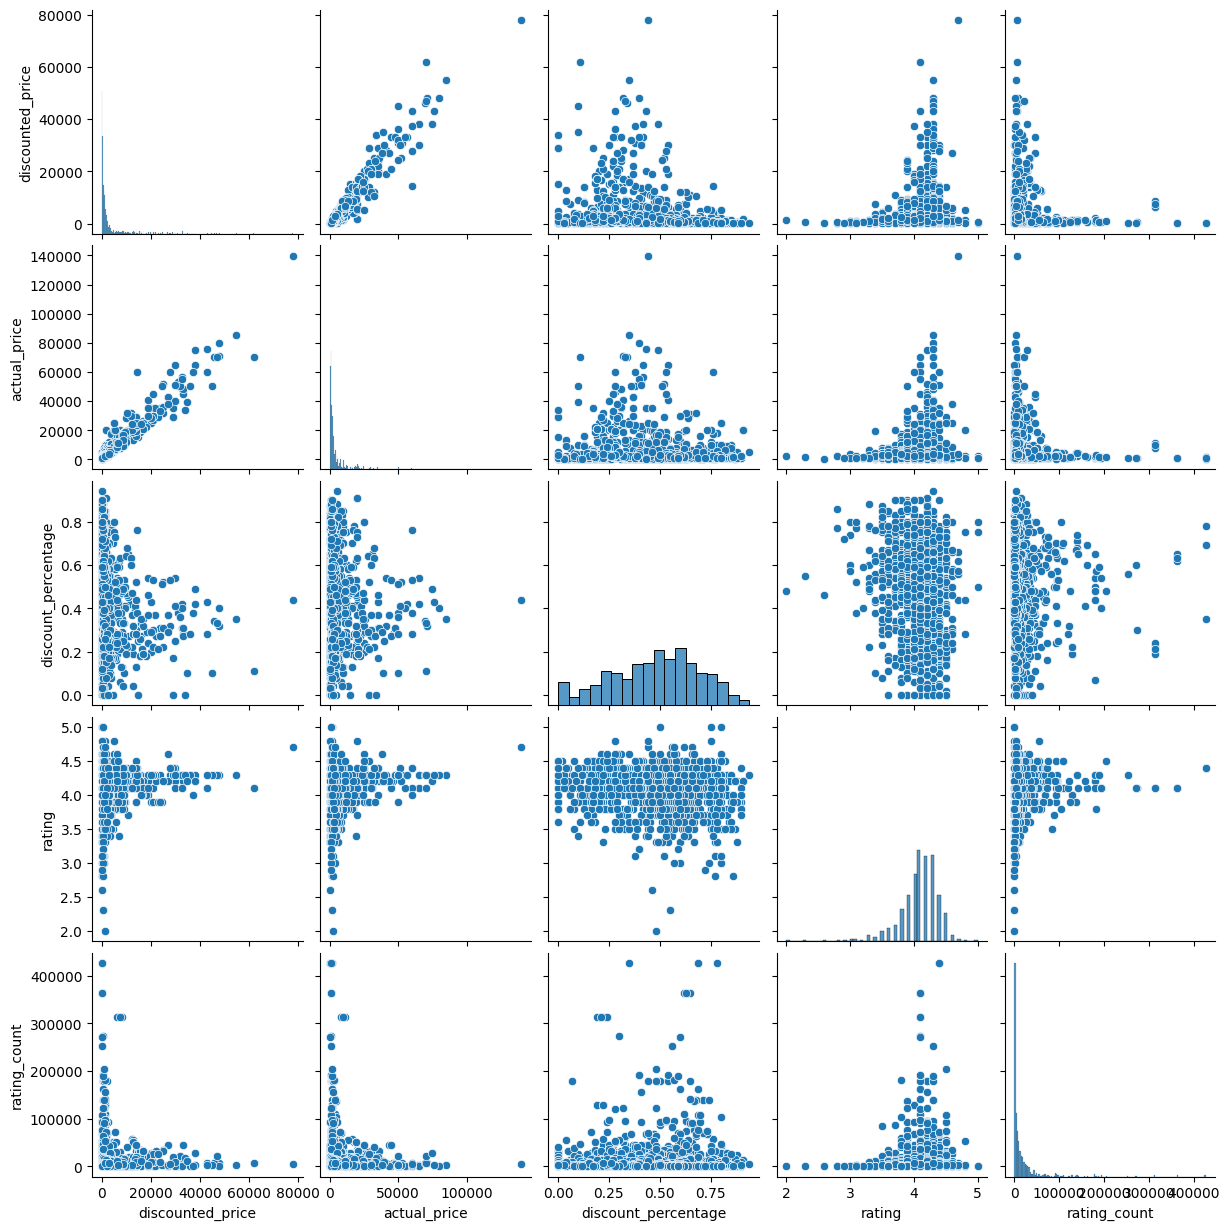

In [14]:
sns.pairplot(df_numeric[cols])
plt.show()

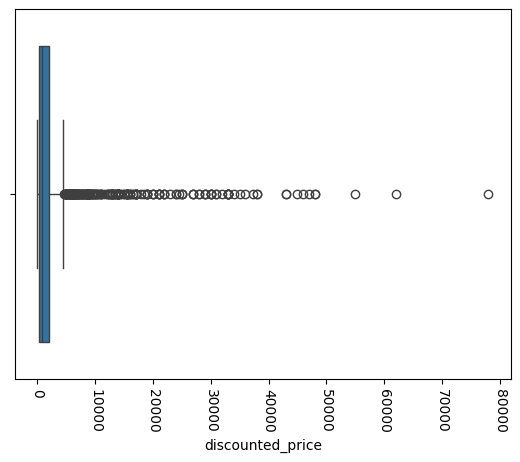

In [54]:
sns.boxplot(x=df_numeric["discounted_price"])
plt.xticks(rotation=270)
plt.show()

**DATA CLEANING**

In [16]:
df_cleaning = df_numeric.copy()

In [17]:
df_cleaning.dropna(inplace=True)
df_cleaning.drop_duplicates(inplace=True)

In [18]:
df_cleaning.isnull().sum()

,0
product_id,0
product_name,0
category,0
discounted_price,0
actual_price,0
discount_percentage,0
rating,0
rating_count,0
about_product,0
user_id,0


In [19]:
df_cleaning.duplicated().sum()

np.int64(0)

In [20]:
Q1 = df_numeric["actual_price"].quantile(0.25)
Q3 = df_numeric["actual_price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_numeric[(df_numeric["actual_price"] < lower_bound) | (df_numeric["actual_price"] > upper_bound)]

print(outliers)

      product_id                                       product_name  \
16    B0B6F7LX4C  MI 80 cm (32 inches) 5A Series HD Ready Smart ...   
19    B08DPLCM6T  LG 80 cm (32 inches) HD Ready Smart LED TV 32L...   
22    B09F6S8BT6  Samsung 80 cm (32 Inches) Wondertainment Serie...   
24    B0B1YVCJ2Y  Acer 80 cm (32 inches) I Series HD Ready Andro...   
26    B08B42LWKN  OnePlus 80 cm (32 inches) Y Series HD Ready LE...   
...          ...                                                ...   
1416  B0BJ6P3LSK  Aqua d pure Active Copper 12-L RO+UV Water Fil...   
1430  B092R48XXB  Mi Robot Vacuum-Mop P Best-in-class Laser Navi...   
1432  B0977CGNJJ  AGARO Royal Stand 1000W Mixer with 5L SS Bowl ...   
1437  B00JBNZPFM  Karcher WD3 EU Wet and Dry Vacuum Cleaner 1000...   
1438  B08N6P8G5K  INALSA Air Fryer Digital 4L Nutri Fry - 1400W ...   

                                               category  discounted_price  \
16    Electronics|HomeTheaterTV&Video|Televisions|Sm...           1399

In [21]:
print("Number of outliers:", len(outliers))

Number of outliers: 213


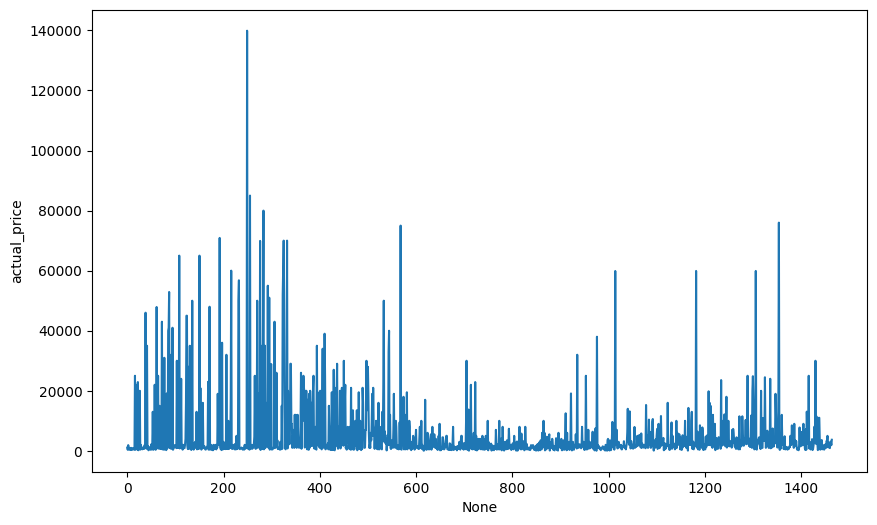

In [22]:
plt.figure(figsize=(10, 6))
sns.lineplot(x=df_cleaning.index, y=df_cleaning["actual_price"])
plt.show()

**DATA PREPROCESSING**

In [23]:
final_df = df_cleaning.copy()

In [24]:
final_df

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,0.64,4.2,24269.0,High Compatibility : Compatible With iPhone 12...,AG3D6O4STAQKAY2UVGEUV46KN35QAHMY5CWJMMK5BJRBBS...,ManavAdarsh guptaSundeepS.Sayeed Ahmedjaspreet...,R3HXWT0LRP0NMFR2AJM3LFTLZHFOR6AQJGUP6P86R1KD19...,SatisfiedCharging is really fastValue for mone...,Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,0.43,4.0,43994.0,Compatible with all Type C enabled devices be ...,AECPFYFQVRUWC3KGNLJIOREFP5LQAGYYVPDD7YG7FYNBXN...,ArdKnNirbhay kumarSagar ViswanathanAspPlacehol...,RGIQEG07R9HS2R1SMWZQ86XIN8UR2J3Y1WL29GWDERYGGS...,A Good Braided Cable for Your Type C DeviceGoo...,I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,0.90,3.9,7928.0,【 Fast Charger& Data Sync】-With built-in safet...,AGU3BBQ2V2DDAMOAKGFAWDDQ6QHAAESFLDV2PT363T2AQL...,KunalHimanshuviswanathsai niharkasaqib malikAa...,R3J3EQQ9TZI5ZJR3E7WBGK7ID0KVRWU79XKQ6I1QFR25X4...,Good speed for earlier versionsGood ProductWor...,Not quite durable and sturdyhttps://m.media-am...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,0.53,4.2,94363.0,The boAt Deuce USB 300 2 in 1 cable is compati...,AEWAZDZZJLQUYVOVGBEUKSLXHQ5AAG5HTSFRRE6NL3M5SG...,Omkar dhaleJDHEMALATHAAjwadh a.amar singh chou...,R3EEUZKKK9J36IR3HJVYCLYOY554REDECAZ7AMPQCR1CLH...,Good productGood oneNiceReally nice productVer...,Good productlong wireCharges goodNiceI bought ...,https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,0.61,4.2,16905.0,[CHARGE & SYNC FUNCTION]- This cable comes wit...,AE3Q6KSUK5P75D5HFYHCRAOLODSAAFUGIFH5ZAFXRDSZHM...,rahuls6099Swasat BorahAjay WadkePranaliRVKBhar...,R1BP4L2HH9TFUPR16PVJEXKV6QZSR2UPDB81N66T4PR3KK...,As good as originalDecentGood one for secondar...,Bought this instead of original apple does the...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1460,B08L7J3T31,Noir Aqua - 5pcs PP Spun Filter + 1 Spanner | ...,Home&Kitchen|Kitchen&HomeAppliances|WaterPurif...,379.0,919.0,0.59,4.0,1090.0,SUPREME QUALITY 90 GRAM 3 LAYER THIK PP SPUN F...,AHITFY6AHALOFOHOZEOC6XBP4FEAAFRABBODZJZQB6Z4U5...,Prabha dsRaghuram bkReal DealAmazon CustomerG1...,R3G3XFHPBFF0E8R3C0BZCD32EIGWR2EBVBCN9QPD9RR9SA...,Received the product without spannerExcellent ...,I received product without spannerExcellent pr...,https://m.media-amazon.com/images/I/41fDdRtjfx...,https://www.amazon.in/Noir-Aqua-Spanner-Purifi...
1461,B01M6453MB,Prestige Delight PRWO Electric Rice Cooker (1 ...,Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...,2280.0,3045.0,0.25,4.1,4118.0,230 Volts 400 watts 1 Year,AFG5FM3NEMOL6BNFRV2NK5FNJCHQAGEINTRN6Z563RMLHI...,Manu BhaiNaveenpittuEvatira SangmaJAGANNADHA R...,R3DDL2UPKQ2CK9R2SYYU1OATVIU5R1VM993161IYRWR28K...,okeverything was good couldn't return bcoz I n...,okgot everything as mentioned but the measurin...,https://m.media-amazon.com/images/I/41gzDxk4+k...,https://

In [25]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
final_df['category_encoded'] = label_encoder.fit_transform(final_df['category'])
print(final_df[['category', 'category_encoded']].head())
print(final_df.info())

                                            category  category_encoded
0  Computers&Accessories|Accessories&Peripherals|...                10
1  Computers&Accessories|Accessories&Peripherals|...                10
2  Computers&Accessories|Accessories&Peripherals|...                10
3  Computers&Accessories|Accessories&Peripherals|...                10
4  Computers&Accessories|Accessories&Peripherals|...                10
<class 'pandas.core.frame.DataFrame'>
Index: 1462 entries, 0 to 1464
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1462 non-null   object 
 1   product_name         1462 non-null   object 
 2   category             1462 non-null   object 
 3   discounted_price     1462 non-null   float64
 4   actual_price         1462 non-null   float64
 5   discount_percentage  1462 non-null   float64
 6   rating               1462 non-null   float64
 7   rating_count     

In [26]:
final_df

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link,category_encoded
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,0.64,4.2,24269.0,High Compatibility : Compatible With iPhone 12...,AG3D6O4STAQKAY2UVGEUV46KN35QAHMY5CWJMMK5BJRBBS...,ManavAdarsh guptaSundeepS.Sayeed Ahmedjaspreet...,R3HXWT0LRP0NMFR2AJM3LFTLZHFOR6AQJGUP6P86R1KD19...,SatisfiedCharging is really fastValue for mone...,Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...,10
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,0.43,4.0,43994.0,Compatible with all Type C enabled devices be ...,AECPFYFQVRUWC3KGNLJIOREFP5LQAGYYVPDD7YG7FYNBXN...,ArdKnNirbhay kumarSagar ViswanathanAspPlacehol...,RGIQEG07R9HS2R1SMWZQ86XIN8UR2J3Y1WL29GWDERYGGS...,A Good Braided Cable for Your Type C DeviceGoo...,I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...,10
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,0.90,3.9,7928.0,【 Fast Charger& Data Sync】-With built-in safet...,AGU3BBQ2V2DDAMOAKGFAWDDQ6QHAAESFLDV2PT363T2AQL...,KunalHimanshuviswanathsai niharkasaqib malikAa...,R3J3EQQ9TZI5ZJR3E7WBGK7ID0KVRWU79XKQ6I1QFR25X4...,Good speed for earlier versionsGood ProductWor...,Not quite durable and sturdyhttps://m.media-am...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...,10
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,0.53,4.2,94363.0,The boAt Deuce USB 300 2 in 1 cable is compati...,AEWAZDZZJLQUYVOVGBEUKSLXHQ5AAG5HTSFRRE6NL3M5SG...,Omkar dhaleJDHEMALATHAAjwadh a.amar singh chou...,R3EEUZKKK9J36IR3HJVYCLYOY554REDECAZ7AMPQCR1CLH...,Good productGood oneNiceReally nice productVer...,Good productlong wireCharges goodNiceI bought ...,https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...,10
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,0.61,4.2,16905.0,[CHARGE & SYNC FUNCTION]- This cable comes wit...,AE3Q6KSUK5P75D5HFYHCRAOLODSAAFUGIFH5ZAFXRDSZHM...,rahuls6099Swasat BorahAjay WadkePranaliRVKBhar...,R1BP4L2HH9TFUPR16PVJEXKV6QZSR2UPDB81N66T4PR3KK...,As good as originalDecentGood one for secondar...,Bought this instead of original apple does the...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1460,B08L7J3T31,Noir Aqua - 5pcs PP Spun Filter + 1 Spanner | ...,Home&Kitchen|Kitchen&HomeAppliances|WaterPurif...,379.0,919.0,0.59,4.0,1090.0,SUPREME QUALITY 90 GRAM 3 LAYER THIK PP SPUN F...,AHITFY6AHALOFOHOZEOC6XBP4FEAAFRABBODZJZQB6Z4U5...,Prabha dsRaghuram bkReal DealAmazon CustomerG1...,R3G3XFHPBFF0E8R3C0BZCD32EIGWR2EBVBCN9QPD9RR9SA...,Received the product without spannerExcellent ...,I received product without spannerExcellent pr...,https://m.media-amazon.com/images/I/41fDdRtjfx...,https://www.amazon.in/Noir-Aqua-Spanner-Purifi...,192
1461,B01M6453MB,Prestige Delight PRWO Electric Rice Cooker (1 ...,Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...,2280.0,3045.0,0.25,4.1,4118.0,230 Volts 400 watts 1 Year,AFG5FM3NEMOL6BNFRV2NK5FNJCHQAGEINTRN6Z563RMLHI...,Manu BhaiNaveenpittuEvatira SangmaJAGANNADHA R...,R3DDL2UPKQ2CK9R2SYYU1OATVIU5R1VM993161IYRWR28K...,okeverything was good couldn't return bcoz I n...,okgot everything as mentioned but the measurin...,https://m.media-am

In [27]:
final_df = pd.get_dummies(final_df, columns=['category'], dtype=int)

In [28]:
final_df.head()

,product_id,product_name,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,...,category_OfficeProducts|OfficePaperProducts|Paper|Stationery|NotebooksWritingPads&Diaries|CompositionNotebooks,category_OfficeProducts|OfficePaperProducts|Paper|Stationery|NotebooksWritingPads&Diaries|Notepads&MemoBooks,category_OfficeProducts|OfficePaperProducts|Paper|Stationery|NotebooksWritingPads&Diaries|WireboundNotebooks,category_OfficeProducts|OfficePaperProducts|Paper|Stationery|PensPencils&WritingSupplies|Pens&Refills|BottledInk,category_OfficeProducts|OfficePaperProducts|Paper|Stationery|PensPencils&WritingSupplies|Pens&Refills|FountainPens,category_OfficeProducts|OfficePaperProducts|Paper|Stationery|PensPencils&WritingSupplies|Pens&Refills|GelInkRollerballPens,category_OfficeProducts|OfficePaperProducts|Paper|Stationery|PensPencils&WritingSupplies|Pens&Refills|LiquidInkRollerballPens,category_OfficeProducts|OfficePaperProducts|Paper|Stationery|PensPencils&WritingSupplies|Pens&Refills|RetractableBallpointPens,category_OfficeProducts|OfficePaperProducts|Paper|Stationery|PensPencils&WritingSupplies|Pens&Refills|StickBallpointPens,category_Toys&Games|Arts&Crafts|Drawing&PaintingSupplies|ColouringPens&Markers
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,399.0,1099.0,0.64,4.2,24269.0,High Compatibility : Compatible With iPhone 12...,AG3D6O4STAQKAY2UVGEUV46KN35QAHMY5CWJMMK5BJRBBS...,ManavAdarsh guptaSundeepS.Sayeed Ahmedjaspreet...,...,0,0,0,0,0,0,0,0,0,0
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,199.0,349.0,0.43,4.0,43994.0,Compatible with all Type C enabled devices be ...,AECPFYFQVRUWC3KGNLJIOREFP5LQAGYYVPDD7YG7FYNBXN...,ArdKnNirbhay kumarSagar ViswanathanAspPlacehol...,...,0,0,0,0,0,0,0,0,0,0
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,199.0,1899.0,0.90,3.9,7928.0,【 Fast Charger& Data Sync】-With built-in safet...,AGU3BBQ2V2DDAMOAKGFAWDDQ6QHAAESFLDV2PT363T2AQL...,KunalHimanshuviswanathsai niharkasaqib malikAa...,...,0,0,0,0,0,0,0,0,0,0
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,329.0,699.0,0.53,4.2,94363.0,The boAt Deuce USB 300 2 in 1 cable is compati...,AEWAZDZZJLQUYVOVGBEUKSLXHQ5AAG5HTSFRRE6NL3M5SG...,Omkar dhaleJDHEMALATHAAjwadh a.amar singh chou...,...,0,0,0,0,0,0,0,0,0,0
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,154.0,399.0,0.61,4.2,16905.0,[CHARGE & SYNC FUNCTION]- This cable comes wit...,AE3Q6KSUK5P75D5HFYHCRAOLODSAAFUGIFH5ZAFXRDSZHM...,rahuls6099Swasat BorahAjay WadkePranaliRVKBhar...,...,0,0,0,0,0,0,0,0,0,0


In [29]:
cols_to_process = [col for col in ['product_name', 'about_product', 'user_id', 'user_name'] if col in final_df.columns]

if cols_to_process:
    final_df = pd.get_dummies(final_df, columns=cols_to_process, dtype=int)
else:
    print("None of the specified columns ('product_name', 'about_product', 'user_id', 'user_name') were found in the DataFrame to be one-hot encoded.")

In [31]:
final_df

,product_id,discounted_price,actual_price,discount_percentage,rating,rating_count,review_id,review_title,review_content,img_link,...,user_name_virender malhotraVikas kabraDasNaveenAmazon CustomerAdv. Manish kotwaniVinod JadhaoPriti tijare,user_name_vivek vinodrobin mohantySadique a.HarshrajatJayJanardhanamHrishikesh,user_name_yashAmazon CustomerNagababuKrunal PatelOmi MayekarIrfan HussainArifharshit,user_name_yogita ratreArun k.Amol BasutkarjanarthananNamankeshav ChelmetiHritik jainJatin Shah,user_name_zainDeepakVIMALShiv SagarTamil selvanRakesh yadavPAGOLA SURESHOlivia,user_name_ˢᴰ82ˢᶜ ✔️Manish RautelaSai kiranDinesh SUttamShahrukhADITYA UBARHANDEDeepak Kanwaliya,user_name_अशोक वैष्णवSatishKBKrajendraBuyerOfProductsManjush MohanM.A.SAMAD KHANlaxman pallikonda,user_name_⚡ Pushpendra Singh Patel ⚡MukulSauronAmazon CustomerBumble BeeNareshSerena A LyngdohSohail Quazi,user_name_𝕵𝖆𝖙𝖎𝖓 𝕮𝖍𝖆𝖉𝖍𝖆palpandia153ArvindNithyadhakshinaBasha_NeeratishakerAmazon CustomerD Ravi,user_name_🤘🏻🤘🏻KabiManoj kumar wareomHemant Kumarpawan r.AnshuPavan kamar
0,B07JW9H4J1,399.0,1099.0,0.64,4.2,24269.0,R3HXWT0LRP0NMFR2AJM3LFTLZHFOR6AQJGUP6P86R1KD19...,SatisfiedCharging is really fastValue for mone...,Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,...,0,0,0,0,0,0,0,0,0,0
1,B098NS6PVG,199.0,349.0,0.43,4.0,43994.0,RGIQEG07R9HS2R1SMWZQ86XIN8UR2J3Y1WL29GWDERYGGS...,A Good Braided Cable for Your Type C DeviceGoo...,I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,...,0,0,0,0,0,0,0,0,0,0
2,B096MSW6CT,199.0,1899.0,0.90,3.9,7928.0,R3J3EQQ9TZI5ZJR3E7WBGK7ID0KVRWU79XKQ6I1QFR25X4...,Good speed for earlier versionsGood ProductWor...,Not quite durable and sturdyhttps://m.media-am...,https://m.media-amazon.com/images/W/WEBP_40237...,...,0,0,0,0,0,0,0,0,0,0
3,B08HDJ86NZ,329.0,699.0,0.53,4.2,94363.0,R3EEUZKKK9J36IR3HJVYCLYOY554REDECAZ7AMPQCR1CLH...,Good productGood oneNiceReally nice productVer...,Good productlong wireCharges goodNiceI bought ...,https://m.media-amazon.com/images/I/41V5FtEWPk...,...,0,0,0,0,0,0,0,0,0,0
4,B08CF3B7N1,154.0,399.0,0.61,4.2,16905.0,R1BP4L2HH9TFUPR16PVJEXKV6QZSR2UPDB81N66T4PR3KK...,As good as originalDecentGood one for secondar...,Bought this instead of original apple does the...,https://m.media-amazon.com/images/W/WEBP_40237...,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1460,B08L7J3T31,379.0,919.0,0.59,4.0,1090.0,R3G3XFHPBFF0E8R3C0BZCD32EIGWR2EBVBCN9QPD9RR9SA...,Received the product without spannerExcellent ...,I received product without spannerExcellent pr...,https://m.media-amazon.com/images/I/41fDdRtjfx...,...,0,0,0,0,0,0,0,0,0,0
1461,B01M6453MB,2280.0,3045.0,0.25,4.1,4118.0,R3DDL2UPKQ2CK9R2SYYU1OATVIU5R1VM993161IYRWR28K...,okeverything was good couldn't return bcoz I n...,okgot everything as mentioned but the measurin...,https://m.media-amazon.com/images/I/41gzDxk4+k...,...,0,0,0,0,0,0,0,0,0,0
1462,B009P2LIL4,2219.0,3080.0,0.28,3.6,468.0,R1TLRJVW4STY5IR2O455KRN493R1R3Q5MVGBRIAS2GRDUW...,very goodWork but front melt after 2 monthGood...,plastic but cool body u have to find sturdy su...,https://m.media-amazon.com/images/W/WEBP_40237...,...,0,0,0,0,0,0,0,0,0,0
1463,B00J5DYCCA,1399.0,1890.0,0.26,4.0,8031.0,R39Q2Y79MM9SWKR3079BG1NIH6MBR29A31ZELTZNJMRQ7X...,Fan Speed is slowGood qualityGood productgoodO...,I have installed this in my kitchen working fi...,https://m.media-amazon.com/images/W/WEBP_40237...,...,0,0,0,0,0,0,0,0,0,0


In [32]:
final_df.describe()

,discounted_price,actual_price,discount_percentage,rating,rating_count,category_encoded,category_Car&Motorbike|CarAccessories|InteriorAccessories|AirPurifiers&Ionizers,category_Computers&Accessories|Accessories&Peripherals|Adapters|USBtoUSBAdapters,category_Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCHeadsets,category_Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCMicrophones,...,user_name_virender malhotraVikas kabraDasNaveenAmazon CustomerAdv. Manish kotwaniVinod JadhaoPriti tijare,user_name_vivek vinodrobin mohantySadique a.HarshrajatJayJanardhanamHrishikesh,user_name_yashAmazon CustomerNagababuKrunal PatelOmi MayekarIrfan HussainArifharshit,user_name_yogita ratreArun k.Amol BasutkarjanarthananNamankeshav ChelmetiHritik jainJatin Shah,user_name_zainDeepakVIMALShiv SagarTamil selvanRakesh yadavPAGOLA SURESHOlivia,user_name_ˢᴰ82ˢᶜ ✔️Manish RautelaSai kiranDinesh SUttamShahrukhADITYA UBARHANDEDeepak Kanwaliya,user_name_अशोक वैष्णवSatishKBKrajendraBuyerOfProductsManjush MohanM.A.SAMAD KHANlaxman pallikonda,user_name_⚡ Pushpendra Singh Patel ⚡MukulSauronAmazon CustomerBumble BeeNareshSerena A LyngdohSohail Quazi,user_name_𝕵𝖆𝖙𝖎𝖓 𝕮𝖍𝖆𝖉𝖍𝖆palpandia153ArvindNithyadhakshinaBasha_NeeratishakerAmazon CustomerD Ravi,user_name_🤘🏻🤘🏻KabiManoj kumar wareomHemant Kumarpawan r.AnshuPavan kamar
count,1462.000000,1462.000000,1462.000000,1462.000000,1462.000000,1462.000000,1462.000000,1462.000000,1462.000000,1462.000000,...,1462.000000,1462.000000,1462.000000,1462.000000,1462.000000,1462.000000,1462.000000,1462.000000,1462.000000,1462.000000
mean,3129.981826,5453.087743,0.476724,4.096717,18307.376881,95.205882,0.000684,0.001368,0.000684,0.001368,...,0.002736,0.000684,0.000684,0.002736,0.000684,0.000684,0.000684,0.000684,0.001368,0.000684
std,6950.548042,10884.467444,0.216139,0.289497,42766.096572,60.528242,0.026153,0.036974,0.026153,0.036974,...,0.052253,0.026153,0.026153,0.052253,0.026153,0.026153,0.026153,0.026153,0.036974,0.026153
min,39.000000,39.000000,0.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,325.000000,800.000000,0.320000,4.000000,1191.500000,31.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,799.000000,1670.000000,0.500000,4.100000,5179.000000,97.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1999.000000,4321.250000,0.630000,4.300000,17342.250000,141.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,77990.000000,139900.000000,0.940000,5.000000,426973.000000,210.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [33]:
final_df['product_id'] = final_df['product_id'].astype(bool)
final_df['review_id'] = final_df['review_id'].astype(bool)
final_df['review_title'] = final_df['review_title'].astype(bool)
final_df['review_content'] = final_df['review_content'].astype(bool)
final_df['img_link'] = final_df['img_link'].astype(bool)
final_df['product_link'] = final_df['product_link'].astype(bool)

In [34]:
final_df

,product_id,discounted_price,actual_price,discount_percentage,rating,rating_count,review_id,review_title,review_content,img_link,...,user_name_virender malhotraVikas kabraDasNaveenAmazon CustomerAdv. Manish kotwaniVinod JadhaoPriti tijare,user_name_vivek vinodrobin mohantySadique a.HarshrajatJayJanardhanamHrishikesh,user_name_yashAmazon CustomerNagababuKrunal PatelOmi MayekarIrfan HussainArifharshit,user_name_yogita ratreArun k.Amol BasutkarjanarthananNamankeshav ChelmetiHritik jainJatin Shah,user_name_zainDeepakVIMALShiv SagarTamil selvanRakesh yadavPAGOLA SURESHOlivia,user_name_ˢᴰ82ˢᶜ ✔️Manish RautelaSai kiranDinesh SUttamShahrukhADITYA UBARHANDEDeepak Kanwaliya,user_name_अशोक वैष्णवSatishKBKrajendraBuyerOfProductsManjush MohanM.A.SAMAD KHANlaxman pallikonda,user_name_⚡ Pushpendra Singh Patel ⚡MukulSauronAmazon CustomerBumble BeeNareshSerena A LyngdohSohail Quazi,user_name_𝕵𝖆𝖙𝖎𝖓 𝕮𝖍𝖆𝖉𝖍𝖆palpandia153ArvindNithyadhakshinaBasha_NeeratishakerAmazon CustomerD Ravi,user_name_🤘🏻🤘🏻KabiManoj kumar wareomHemant Kumarpawan r.AnshuPavan kamar
0,True,399.0,1099.0,0.64,4.2,24269.0,True,True,True,True,...,0,0,0,0,0,0,0,0,0,0
1,True,199.0,349.0,0.43,4.0,43994.0,True,True,True,True,...,0,0,0,0,0,0,0,0,0,0
2,True,199.0,1899.0,0.90,3.9,7928.0,True,True,True,True,...,0,0,0,0,0,0,0,0,0,0
3,True,329.0,699.0,0.53,4.2,94363.0,True,True,True,True,...,0,0,0,0,0,0,0,0,0,0
4,True,154.0,399.0,0.61,4.2,16905.0,True,True,True,True,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1460,True,379.0,919.0,0.59,4.0,1090.0,True,True,True,True,...,0,0,0,0,0,0,0,0,0,0
1461,True,2280.0,3045.0,0.25,4.1,4118.0,True,True,True,True,...,0,0,0,0,0,0,0,0,0,0
1462,True,2219.0,3080.0,0.28,3.6,468.0,True,True,True,True,...,0,0,0,0,0,0,0,0,0,0
1463,True,1399.0,1890.0,0.26,4.0,8031.0,True,True,True,True,...,0,0,0,0,0,0,0,0,0,0


In [35]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
final_df['product_id'] = le.fit_transform(final_df['product_id'])
final_df['review_id'] = le.fit_transform(final_df['review_id'])
final_df['review_title'] = le.fit_transform(final_df['review_title'])
final_df['review_content'] = le.fit_transform(final_df['review_content'])
final_df['img_link'] = le.fit_transform(final_df['img_link'])
final_df['product_link'] = le.fit_transform(final_df['product_link'])

In [36]:
final_df

,product_id,discounted_price,actual_price,discount_percentage,rating,rating_count,review_id,review_title,review_content,img_link,...,user_name_virender malhotraVikas kabraDasNaveenAmazon CustomerAdv. Manish kotwaniVinod JadhaoPriti tijare,user_name_vivek vinodrobin mohantySadique a.HarshrajatJayJanardhanamHrishikesh,user_name_yashAmazon CustomerNagababuKrunal PatelOmi MayekarIrfan HussainArifharshit,user_name_yogita ratreArun k.Amol BasutkarjanarthananNamankeshav ChelmetiHritik jainJatin Shah,user_name_zainDeepakVIMALShiv SagarTamil selvanRakesh yadavPAGOLA SURESHOlivia,user_name_ˢᴰ82ˢᶜ ✔️Manish RautelaSai kiranDinesh SUttamShahrukhADITYA UBARHANDEDeepak Kanwaliya,user_name_अशोक वैष्णवSatishKBKrajendraBuyerOfProductsManjush MohanM.A.SAMAD KHANlaxman pallikonda,user_name_⚡ Pushpendra Singh Patel ⚡MukulSauronAmazon CustomerBumble BeeNareshSerena A LyngdohSohail Quazi,user_name_𝕵𝖆𝖙𝖎𝖓 𝕮𝖍𝖆𝖉𝖍𝖆palpandia153ArvindNithyadhakshinaBasha_NeeratishakerAmazon CustomerD Ravi,user_name_🤘🏻🤘🏻KabiManoj kumar wareomHemant Kumarpawan r.AnshuPavan kamar
0,0,399.0,1099.0,0.64,4.2,24269.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,199.0,349.0,0.43,4.0,43994.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,199.0,1899.0,0.90,3.9,7928.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,329.0,699.0,0.53,4.2,94363.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,154.0,399.0,0.61,4.2,16905.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1460,0,379.0,919.0,0.59,4.0,1090.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1461,0,2280.0,3045.0,0.25,4.1,4118.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1462,0,2219.0,3080.0,0.28,3.6,468.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1463,0,1399.0,1890.0,0.26,4.0,8031.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


**DATA MODELING**

In [41]:
from sklearn.model_selection import train_test_split
X = final_df.drop('discounted_price', axis=1)
y = final_df['discounted_price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

In [42]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [44]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [45]:
y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)

In [50]:
from sklearn.metrics import r2_score as r2_score_func
r2_value = r2_score_func(y_test, y_pred)
print(f"R-squared score: {r2_value}")

R-squared score: 0.9709709971904004


In [51]:
mse

847783.2613142979

In [53]:
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2_Score =  1 - (1 - r2_value) * (n - 1) / (n - p - 1)
adjusted_r2_Score

1.0017172748825776